[OK] TaiESM1 | ssp245
[OK] TaiESM1 | ssp370
[OK] TaiESM1 | ssp585
[OK] ACCESS-CM2 | ssp245
[OK] ACCESS-CM2 | ssp370
[OK] ACCESS-CM2 | ssp585
[OK] EC-Earth3 | ssp245
[OK] EC-Earth3 | ssp370
[OK] EC-Earth3 | ssp585
[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\all_generation_counts.csv
        model     ssp  gen_2004  gen_2034  difference  pct_change
0  ACCESS-CM2  ssp245       4.0       5.0         1.0        25.0
1  ACCESS-CM2  ssp370       4.0       5.0         1.0        25.0
2  ACCESS-CM2  ssp585       4.0       4.0         0.0         0.0
3   EC-Earth3  ssp245       4.0       4.0         0.0         0.0
4   EC-Earth3  ssp370       4.0       4.0         0.0         0.0
5   EC-Earth3  ssp585       4.0       4.0         0.0         0.0
6     TaiESM1  ssp245       4.0       5.0         1.0        25.0
7     TaiESM1  ssp370       4.0       4.0         0.0         0.0
8     TaiESM1  ssp585       4.0       5.0         1.0        25.0
[SAVED] C:\Climate_project\程式作業\Daxue＿village\fig

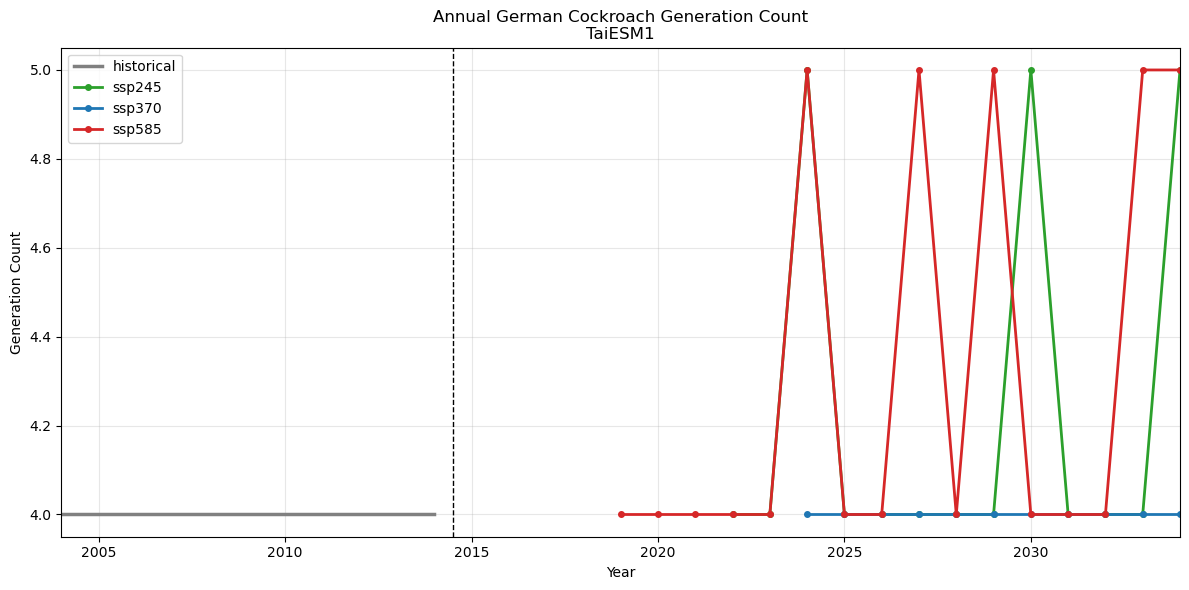

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\TaiESM1_generation_count.png


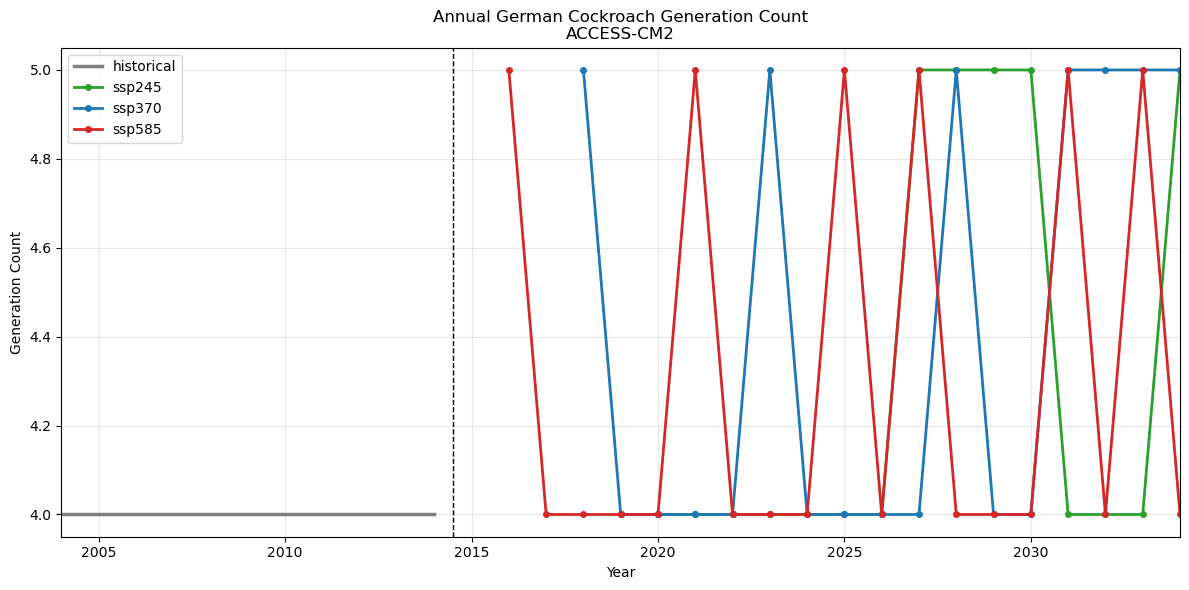

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\ACCESS-CM2_generation_count.png


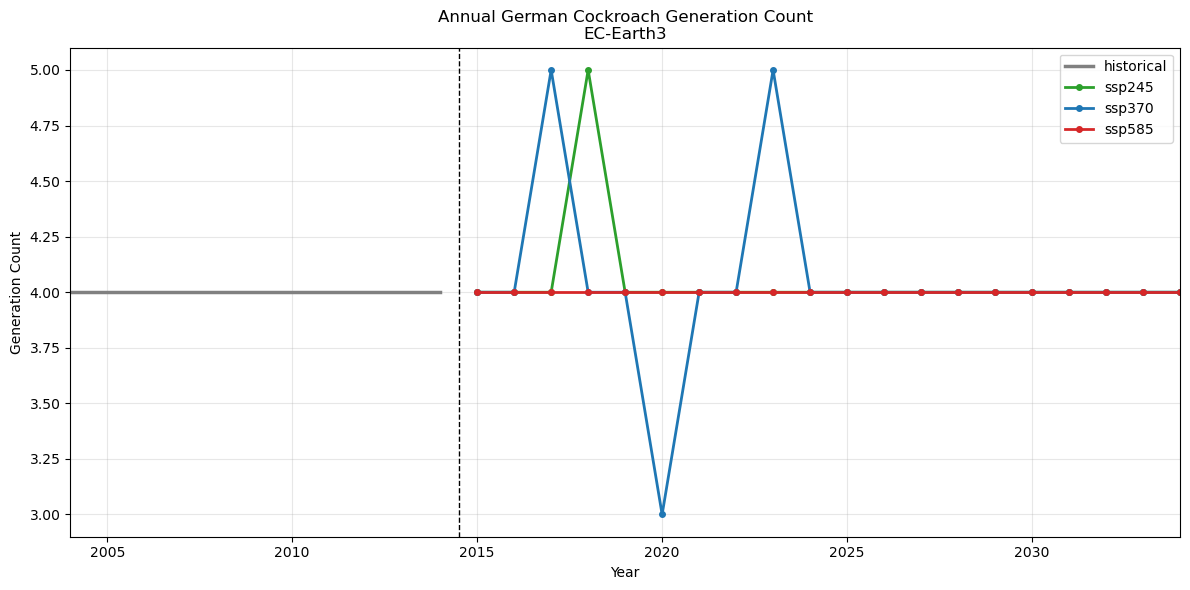

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\EC-Earth3_generation_count.png


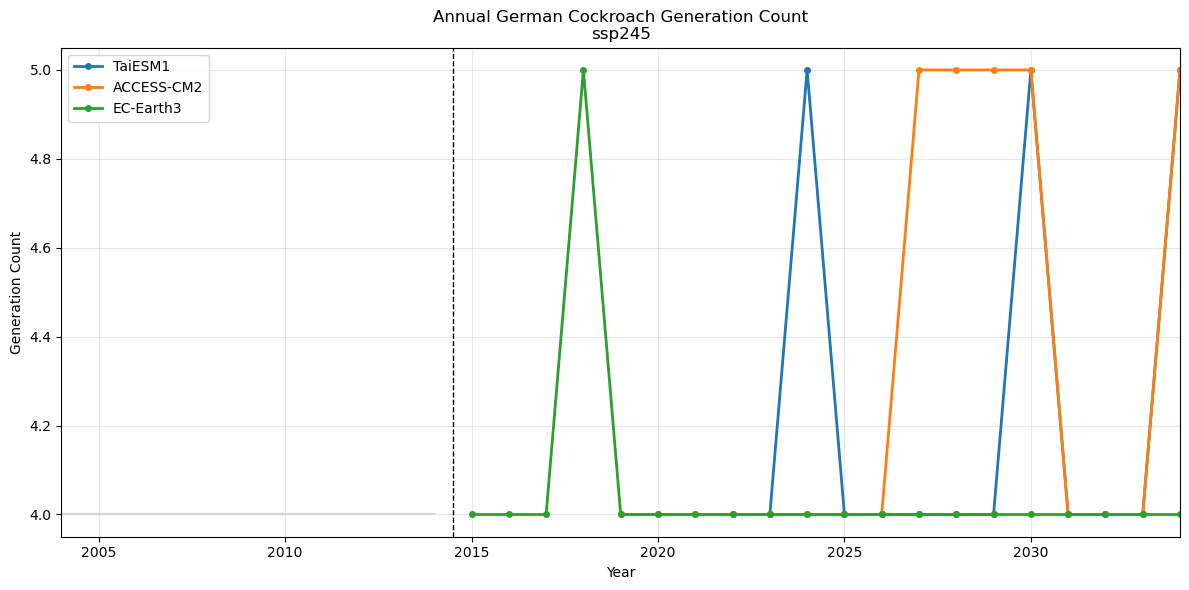

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\ssp245_generation_count_models.png


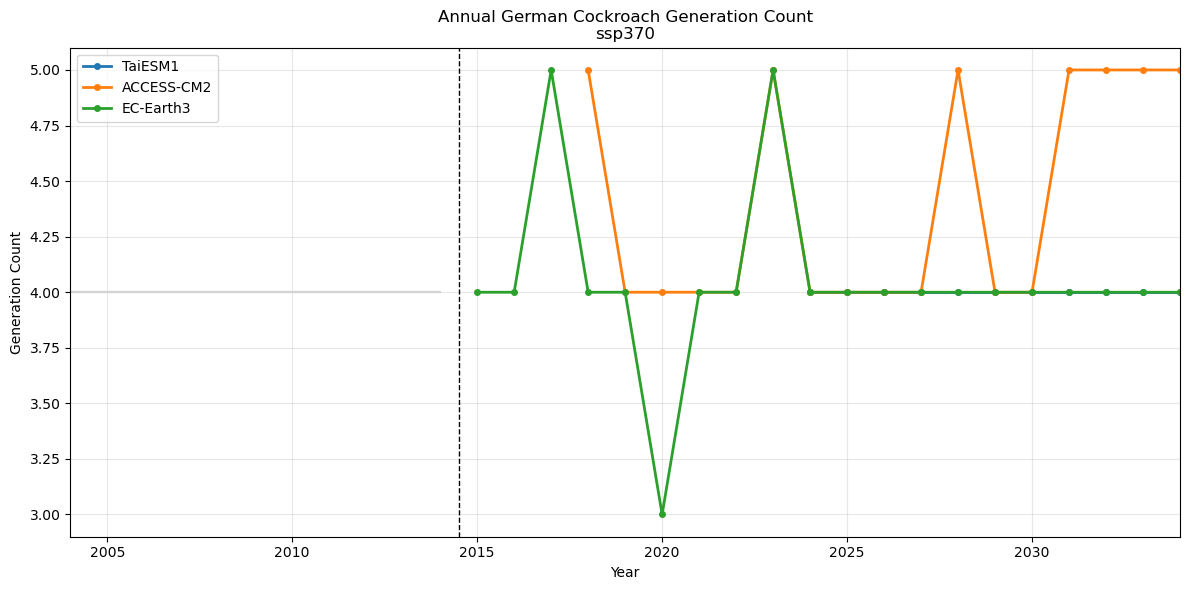

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\ssp370_generation_count_models.png


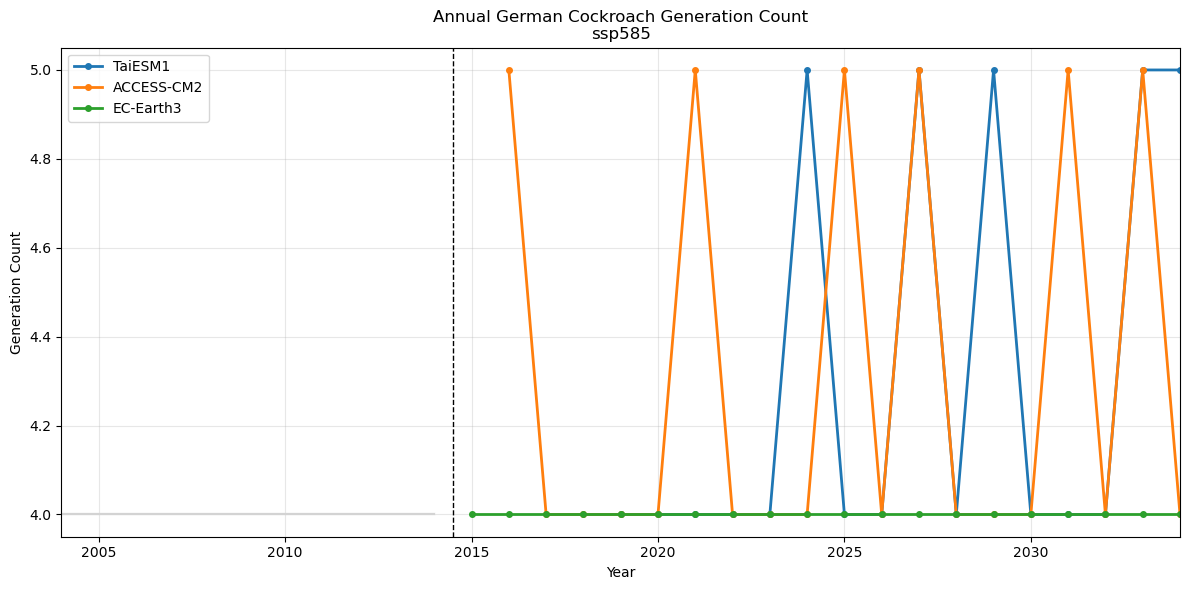

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\ssp585_generation_count_models.png


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =========================================================
# 0. 基本設定
# =========================================================
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

# ===== 路徑：請依你的電腦修改 =====
tmean_gwl_folder = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\GWL1.5")
tmean_hist_folder = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\historical")

save_path = Path(r"C:\Climate_project\程式作業\Daxue＿village\figue")
save_path.mkdir(parents=True, exist_ok=True)

# ===== 你要分析的模式與情境 =====
target_models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
target_ssps = ["ssp245", "ssp370", "ssp585"]

# ===== 時間範圍 =====
hist_start = "2004-01-01"
hist_end   = "2014-12-31"
fut_start  = "2015-01-01"
fut_end    = "2034-12-31"

start_year = 2004
end_year   = 2034

# ===== Degree-Day 參數 =====
T_BASE = 15.9
THERMAL_CONSTANT = 650.0   # degree-days / generation

# ===== 資料品質控制 =====
INVALID_VALUE = -99.9
MIN_VALID_DAYS_PER_YEAR = 330   # 少於這個日數就視為該年不足，不計算
USE_ONLY_POSITIVE_DD = True     # True = max(Tmean - Tbase, 0)

# ===== 視覺化 =====
ssp_colors = {
    "ssp245": "#2ca02c",
    "ssp370": "#1f77b4",
    "ssp585": "#d62728"
}
hist_color = "gray"


# =========================================================
# 1. 基本工具函數
# =========================================================
def safe_filename(text):
    return (
        text.replace(" ", "_")
            .replace(">", "gt")
            .replace("<", "lt")
            .replace("=", "eq")
            .replace("°", "")
            .replace("/", "_")
    )

def read_csv_with_fallback(csv_path: Path):
    encodings = ["utf-8", "utf-8-sig", "big5"]
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error

def extract_year_from_filename(fp: Path):
    m = re.search(r"_(\d{4})\.csv$", fp.name)
    return int(m.group(1)) if m else -1

def get_historical_files(folder: Path, model_name: str):
    files = sorted(folder.glob("*.csv"))
    matched = [f for f in files if model_name in f.name]
    return sorted(matched, key=extract_year_from_filename)

def get_gwl_ssp_files(folder: Path, model_name: str, ssp_name: str):
    files = sorted(folder.glob("*.csv"))
    matched = [f for f in files if (model_name in f.name) and (ssp_name in f.name)]
    return sorted(matched, key=extract_year_from_filename)

def read_point_daily_series_from_csv(csv_path: Path, poi_lon: float, poi_lat: float):
    """
    檔案格式：
    前兩欄 = 經緯度
    後面欄位 = YYYYMMDD
    """
    df = read_csv_with_fallback(csv_path)

    cols_upper = [str(c).upper() for c in df.columns]
    df.columns = cols_upper

    lon_col = df.columns[0]
    lat_col = df.columns[1]

    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")

    dist = np.sqrt((df[lon_col] - poi_lon) ** 2 + (df[lat_col] - poi_lat) ** 2)
    idx = dist.idxmin()
    row = df.loc[idx]

    date_cols = df.columns[2:]
    dates = pd.to_datetime(date_cols, format="%Y%m%d", errors="coerce")
    values = pd.to_numeric(row[date_cols], errors="coerce").replace(INVALID_VALUE, np.nan)

    s = pd.Series(values.values, index=dates)
    s = s[~s.index.isna()].sort_index()

    return s, float(row[lon_col]), float(row[lat_col])

def load_daily_series_from_files(files, poi_lon, poi_lat):
    if len(files) == 0:
        raise FileNotFoundError("找不到檔案")

    series_list = []
    nearest_lon = None
    nearest_lat = None

    for f in files:
        s, lon0, lat0 = read_point_daily_series_from_csv(f, poi_lon, poi_lat)
        series_list.append(s)
        nearest_lon = lon0
        nearest_lat = lat0

    full = pd.concat(series_list, axis=0)
    full = full[~full.index.duplicated(keep="first")]
    full = full.sort_index()

    return full, nearest_lon, nearest_lat

def load_historical_series(folder, model_name, poi_lon, poi_lat):
    files = get_historical_files(folder, model_name)
    return load_daily_series_from_files(files, poi_lon, poi_lat)

def load_gwl_ssp_series(folder, model_name, ssp_name, poi_lon, poi_lat):
    files = get_gwl_ssp_files(folder, model_name, ssp_name)
    return load_daily_series_from_files(files, poi_lon, poi_lat)


# =========================================================
# 2. 合併 historical + future
#    不硬補 daily 資料，只做時間對齊
# =========================================================
def combine_historical_and_ssp(hist_series, ssp_series,
                               hist_start, hist_end,
                               fut_start, fut_end):
    hist_part = hist_series[hist_start:hist_end]
    ssp_part  = ssp_series[fut_start:fut_end]

    combined = pd.concat([hist_part, ssp_part])
    combined = combined.sort_index()
    combined = combined[~combined.index.duplicated(keep="first")]

    return combined

def build_full_daily_series(model_name, ssp_name):
    hist_series, lon0, lat0 = load_historical_series(
        tmean_hist_folder, model_name, poi_lon, poi_lat
    )
    fut_series, _, _ = load_gwl_ssp_series(
        tmean_gwl_folder, model_name, ssp_name, poi_lon, poi_lat
    )

    combined = combine_historical_and_ssp(
        hist_series=hist_series,
        ssp_series=fut_series,
        hist_start=hist_start,
        hist_end=hist_end,
        fut_start=fut_start,
        fut_end=fut_end
    )

    combined = combined[(combined.index.year >= start_year) & (combined.index.year <= end_year)]

    return combined, lon0, lat0


# =========================================================
# 3. Degree-Day / Generation Count
# =========================================================
def calc_generation_count_per_year(
    series,
    t_base=T_BASE,
    thermal_constant=THERMAL_CONSTANT,
    min_valid_days=MIN_VALID_DAYS_PER_YEAR,
    use_only_positive_dd=True
):
    """
    對單一日平均溫序列，逐年計算 generation count

    做法：
    - 每年獨立計算
    - 若該年有效日數不足，該年回傳 NaN
    - 達到 thermal_constant 後，以 while 扣除，保留餘量
      （比「直接歸零」更合理，因為超過門檻的熱量不應浪費）
    """
    s = pd.Series(series).copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()

    years = range(s.index.year.min(), s.index.year.max() + 1)
    rows = []

    for year in years:
        year_s = s[s.index.year == year].dropna()
        valid_days = len(year_s)

        if valid_days < min_valid_days:
            rows.append({
                "year": year,
                "generation_count": np.nan,
                "valid_days": valid_days,
                "annual_dd": np.nan
            })
            continue

        dd = year_s - t_base
        if use_only_positive_dd:
            dd = dd.clip(lower=0)

        dd = dd.fillna(0)
        annual_dd = dd.sum()

        gen_count = 0
        acc = 0.0
        for value in dd.values:
            acc += value
            while acc >= thermal_constant:
                gen_count += 1
                acc -= thermal_constant

        rows.append({
            "year": year,
            "generation_count": gen_count,
            "valid_days": valid_days,
            "annual_dd": annual_dd
        })

    return pd.DataFrame(rows)


# =========================================================
# 4. 單一模式 + 單一 SSP
# =========================================================
def build_generation_df_for_one_model_one_ssp(model_name, ssp_name):
    combined_series, lon0, lat0 = build_full_daily_series(model_name, ssp_name)

    gen_df = calc_generation_count_per_year(
        series=combined_series,
        t_base=T_BASE,
        thermal_constant=THERMAL_CONSTANT,
        min_valid_days=MIN_VALID_DAYS_PER_YEAR,
        use_only_positive_dd=USE_ONLY_POSITIVE_DD
    )

    gen_df["model"] = model_name
    gen_df["ssp"] = ssp_name
    gen_df["lon"] = lon0
    gen_df["lat"] = lat0

    # 標記 historical / future
    gen_df["period"] = np.where(gen_df["year"] <= 2014, "historical", "future")

    return gen_df


# =========================================================
# 5. 多模式 × 多 SSP 批次計算
# =========================================================
def build_all_generation_results(target_models, target_ssps):
    all_list = []

    for model_name in target_models:
        for ssp_name in target_ssps:
            try:
                df_one = build_generation_df_for_one_model_one_ssp(model_name, ssp_name)
                all_list.append(df_one)
                print(f"[OK] {model_name} | {ssp_name}")
            except Exception as e:
                print(f"[FAIL] {model_name} | {ssp_name}: {e}")

    if len(all_list) == 0:
        raise RuntimeError("沒有任何結果成功產生")

    out = pd.concat(all_list, ignore_index=True)
    return out


# =========================================================
# 6. 空白年份處理
# =========================================================
def fill_missing_years_for_plot_only(df, value_col="generation_count"):
    """
    只為了畫圖好看：
    - 補齊年份
    - 對 annual generation count 做插值
    - 正式分析不要用這版數值
    """
    df = df.copy()
    year_min = df["year"].min()
    year_max = df["year"].max()

    full_years = pd.DataFrame({"year": np.arange(year_min, year_max + 1)})
    df2 = full_years.merge(df, on="year", how="left")

    # 保留 model / ssp / period 結構
    if "model" in df.columns and df["model"].notna().any():
        df2["model"] = df["model"].dropna().iloc[0]
    if "ssp" in df.columns and df["ssp"].notna().any():
        df2["ssp"] = df["ssp"].dropna().iloc[0]

    df2["period"] = np.where(df2["year"] <= 2014, "historical", "future")
    df2[f"{value_col}_interp"] = df2[value_col].interpolate(method="linear", limit_direction="both")

    return df2


# =========================================================
# 7. 繪圖：同一模式，不同 SSP
# =========================================================
def plot_generation_by_model(all_df, model_name, save_path,
                             show_interp=False):
    sub = all_df[all_df["model"] == model_name].copy()

    if sub.empty:
        print(f"[WARN] {model_name} 沒有資料")
        return

    plt.figure(figsize=(12, 6))

    # historical 只畫一次（因為每個 SSP 的歷史段其實相同）
    hist_sub = sub[sub["period"] == "historical"].drop_duplicates(subset=["year"]).sort_values("year")
    plt.plot(
        hist_sub["year"], hist_sub["generation_count"],
        color=hist_color, linewidth=2.5, label="historical"
    )

    # future 各 SSP
    for ssp_name in target_ssps:
        fut_sub = sub[(sub["ssp"] == ssp_name) & (sub["period"] == "future")].sort_values("year")

        plt.plot(
            fut_sub["year"], fut_sub["generation_count"],
            color=ssp_colors.get(ssp_name, None),
            linewidth=2,
            marker="o",
            ms=4,
            label=ssp_name
        )

        if show_interp:
            tmp = fill_missing_years_for_plot_only(fut_sub, value_col="generation_count")
            plt.plot(
                tmp["year"], tmp["generation_count_interp"],
                color=ssp_colors.get(ssp_name, None),
                linestyle="--",
                alpha=0.35
            )

    plt.axvline(2014.5, color="black", linestyle="--", linewidth=1)
    plt.title(f"Annual German Cockroach Generation Count\n{model_name}")
    plt.xlabel("Year")
    plt.ylabel("Generation Count")
    plt.xlim(start_year, end_year)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out_fp = save_path / f"{safe_filename(model_name)}_generation_count.png"
    plt.savefig(out_fp, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"[SAVED] {out_fp}")


# =========================================================
# 8. 繪圖：同一 SSP，不同模式
# =========================================================
def plot_generation_by_ssp(all_df, ssp_name, save_path):
    sub = all_df[all_df["ssp"] == ssp_name].copy()

    if sub.empty:
        print(f"[WARN] {ssp_name} 沒有資料")
        return

    plt.figure(figsize=(12, 6))

    for model_name in target_models:
        model_sub = sub[sub["model"] == model_name].sort_values("year")
        if model_sub.empty:
            continue

        hist_sub = model_sub[model_sub["period"] == "historical"]
        fut_sub = model_sub[model_sub["period"] == "future"]

        plt.plot(
            hist_sub["year"], hist_sub["generation_count"],
            color="lightgray", linewidth=1.5, alpha=0.8
        )
        plt.plot(
            fut_sub["year"], fut_sub["generation_count"],
            linewidth=2, marker="o", ms=4, label=model_name
        )

    plt.axvline(2014.5, color="black", linestyle="--", linewidth=1)
    plt.title(f"Annual German Cockroach Generation Count\n{ssp_name}")
    plt.xlabel("Year")
    plt.ylabel("Generation Count")
    plt.xlim(start_year, end_year)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out_fp = save_path / f"{safe_filename(ssp_name)}_generation_count_models.png"
    plt.savefig(out_fp, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"[SAVED] {out_fp}")


# =========================================================
# 9. 輸出摘要表
# =========================================================
def build_summary_table(all_df):
    """
    輸出每個 model / ssp 的：
    - 2004 generation count
    - 2034 generation count
    - 差值
    - 百分比變化
    """
    rows = []

    grouped = all_df.groupby(["model", "ssp"])
    for (model_name, ssp_name), g in grouped:
        g = g.sort_values("year")

        val_2004 = g.loc[g["year"] == 2004, "generation_count"]
        val_2034 = g.loc[g["year"] == 2034, "generation_count"]

        x = val_2004.iloc[0] if len(val_2004) else np.nan
        y = val_2034.iloc[0] if len(val_2034) else np.nan

        diff = y - x if pd.notna(x) and pd.notna(y) else np.nan
        pct = (diff / x * 100) if pd.notna(x) and pd.notna(y) and x != 0 else np.nan

        rows.append({
            "model": model_name,
            "ssp": ssp_name,
            "gen_2004": x,
            "gen_2034": y,
            "difference": diff,
            "pct_change": pct
        })

    return pd.DataFrame(rows).sort_values(["model", "ssp"])


# =========================================================
# 10. 執行
# =========================================================
all_generation_df = build_all_generation_results(target_models, target_ssps)

# 儲存完整表
all_csv = save_path / "all_generation_counts.csv"
all_generation_df.to_csv(all_csv, index=False, encoding="utf-8-sig")
print(f"[SAVED] {all_csv}")

# 摘要表
summary_df = build_summary_table(all_generation_df)
summary_csv = save_path / "generation_summary_2004_vs_2034.csv"
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")
print(summary_df)
print(f"[SAVED] {summary_csv}")

# 畫圖：每個模式一張
for model_name in target_models:
    plot_generation_by_model(
        all_df=all_generation_df,
        model_name=model_name,
        save_path=save_path,
        show_interp=False   # 正式分析建議 False；若只是想讓圖連續可改 True
    )

# 畫圖：每個 SSP 一張
for ssp_name in target_ssps:
    plot_generation_by_ssp(
        all_df=all_generation_df,
        ssp_name=ssp_name,
        save_path=save_path
    )

In [4]:
import pandas as pd

# 讀取 summary
summary_path = r"C:\Climate_project\程式作業\Daxue＿village\figue\generation_summary_2004_vs_2034.csv"  # 若在本機請改路徑
df = pd.read_csv(summary_path)

def generate_result_sentence(row):
    model = row["model"]
    ssp = row["ssp"]
    x = row["gen_2004"]
    y = row["gen_2034"]
    pct = row["pct_change"]

    if pd.isna(x) or pd.isna(y):
        return f"{model} ({ssp}): insufficient data"

    return (
        f"In {model} under {ssp}, the number of annual generations increases "
        f"from {x:.1f} in 2004 to {y:.1f} in 2034, representing a {pct:.1f}% increase."
    )

df["sentence"] = df.apply(generate_result_sentence, axis=1)

for s in df["sentence"]:
    print(s)

In ACCESS-CM2 under ssp245, the number of annual generations increases from 4.0 in 2004 to 5.0 in 2034, representing a 25.0% increase.
In ACCESS-CM2 under ssp370, the number of annual generations increases from 4.0 in 2004 to 5.0 in 2034, representing a 25.0% increase.
In ACCESS-CM2 under ssp585, the number of annual generations increases from 4.0 in 2004 to 4.0 in 2034, representing a 0.0% increase.
In EC-Earth3 under ssp245, the number of annual generations increases from 4.0 in 2004 to 4.0 in 2034, representing a 0.0% increase.
In EC-Earth3 under ssp370, the number of annual generations increases from 4.0 in 2004 to 4.0 in 2034, representing a 0.0% increase.
In EC-Earth3 under ssp585, the number of annual generations increases from 4.0 in 2004 to 4.0 in 2034, representing a 0.0% increase.
In TaiESM1 under ssp245, the number of annual generations increases from 4.0 in 2004 to 5.0 in 2034, representing a 25.0% increase.
In TaiESM1 under ssp370, the number of annual generations increas

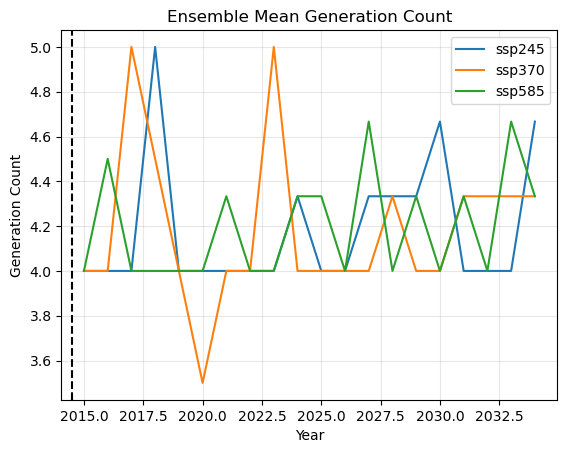

In [5]:
df = pd.read_csv( r"C:\Climate_project\程式作業\Daxue＿village\figue\all_generation_counts.csv")

# 只看 future
df_future = df[df["period"] == "future"]

ensemble = (
    df_future.groupby(["year", "ssp"])["generation_count"]
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt

for ssp in ensemble["ssp"].unique():
    sub = ensemble[ensemble["ssp"] == ssp]
    plt.plot(sub["year"], sub["generation_count"], label=ssp)

plt.axvline(2014.5, linestyle="--", color="black")
plt.title("Ensemble Mean Generation Count")
plt.xlabel("Year")
plt.ylabel("Generation Count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

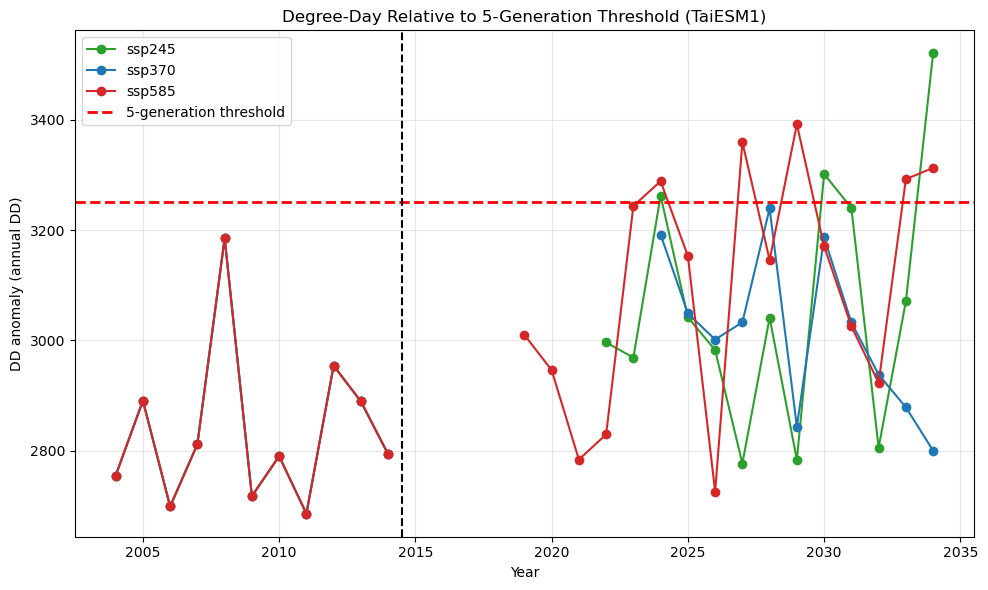

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\dd_anomaly_plot\TaiESM1_dd.png


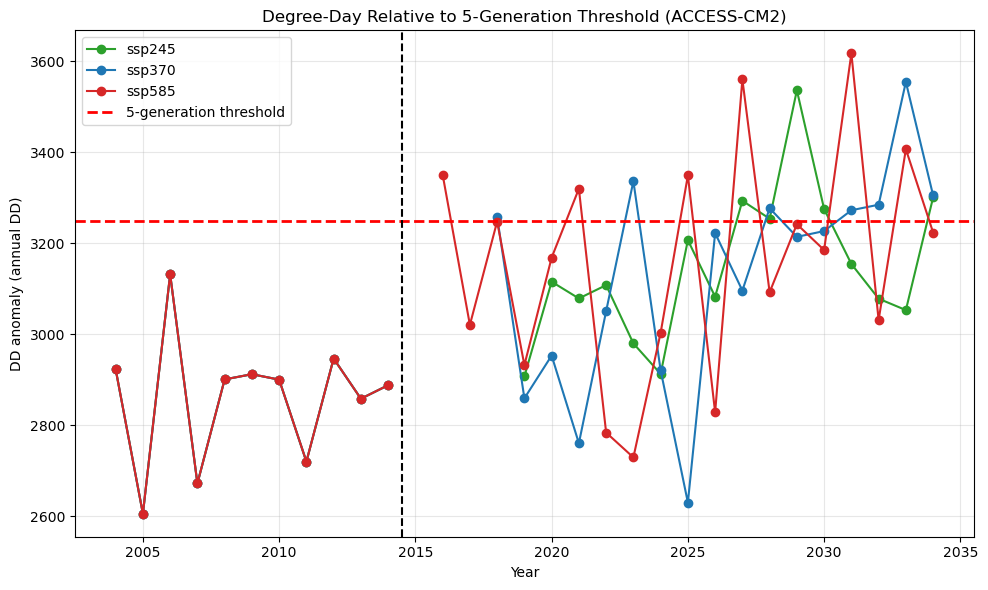

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\dd_anomaly_plot\ACCESS-CM2_dd.png


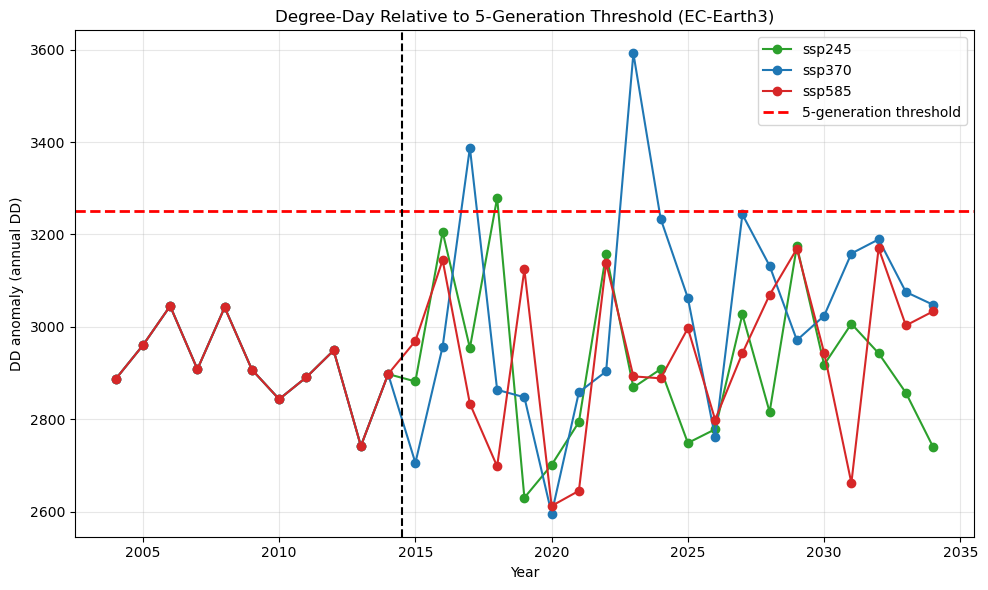

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\dd_anomaly_plot\EC-Earth3_dd.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===== 讀資料 =====
df = pd.read_csv(r"C:\Climate_project\程式作業\Daxue＿village\figue\all_generation_counts.csv")  # 改成本機路徑

# ===== 參數 =====
THERMAL_CONSTANT = 650
BASELINE_GEN = 4

threshold_dd = (BASELINE_GEN + 1) * THERMAL_CONSTANT   # 3250

# ===== 計算 anomaly =====
df["dd_anomaly"] = df["annual_dd"] #- threshold_dd

# ===== 顏色 =====
ssp_colors = {
    "ssp245": "#2ca02c",
    "ssp370": "#1f77b4",
    "ssp585": "#d62728"
}

# ===== 輸出資料夾 =====
save_path = Path(r"C:\Climate_project\程式作業\Daxue＿village\figue\dd_anomaly_plot")
save_path.mkdir(exist_ok=True)

# =========================================================
# 畫圖（每個 model 一張）
# =========================================================
for model in df["model"].unique():
    sub = df[df["model"] == model].copy()

    plt.figure(figsize=(10, 6))

    for ssp in sub["ssp"].unique():
        ssp_sub = sub[sub["ssp"] == ssp].sort_values("year")

        plt.plot(
            ssp_sub["year"],
            ssp_sub["dd_anomaly"],
            label=ssp,
            color=ssp_colors.get(ssp, None),
            marker="o"
        )

    # ===== 0 線（門檻）=====
    plt.axhline(
        3250,
        color="red",
        linestyle="--",
        linewidth=2,
        label="5-generation threshold"
    )

    # ===== historical / future 分界 =====
    plt.axvline(2014.5, linestyle="--", color="black")

    plt.title(f"Degree-Day Relative to 5-Generation Threshold ({model})") #Anomaly
    plt.xlabel("Year")
    plt.ylabel("DD anomaly (annual DD)")# - 3250
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout() #_anomaly

    out_fp = save_path / f"{model}_dd.png"
    plt.savefig(out_fp, dpi=200)
    plt.show()

    print(f"[SAVED] {out_fp}")

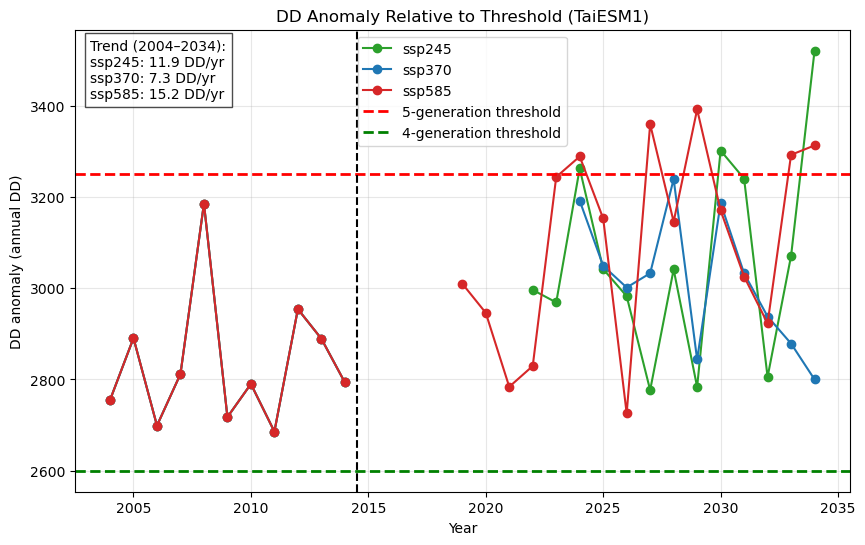

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\dd_anomaly_plot\TaiESM1_dd_trend.png


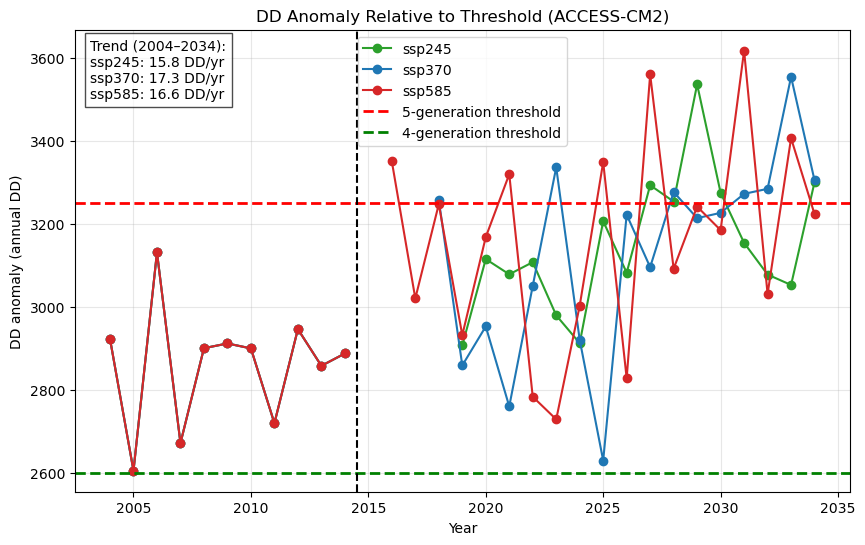

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\dd_anomaly_plot\ACCESS-CM2_dd_trend.png


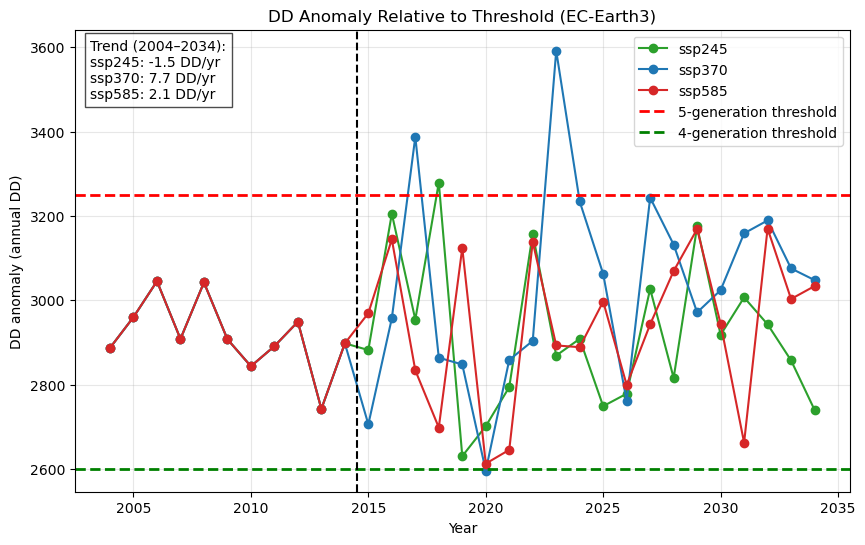

[SAVED] C:\Climate_project\程式作業\Daxue＿village\figue\dd_anomaly_plot\EC-Earth3_dd_trend.png


In [12]:
# ===== 讀資料 =====
df = pd.read_csv(r"C:\Climate_project\程式作業\Daxue＿village\figue\all_generation_counts.csv")

# ===== 參數 =====
THERMAL_CONSTANT = 650
BASELINE_GEN = 4
threshold_dd = (BASELINE_GEN + 1) * THERMAL_CONSTANT  # 3250

# ===== anomaly =====
df["dd_anomaly"] = df["annual_dd"] #- threshold_dd

# ===== 顏色 =====
ssp_colors = {
    "ssp245": "#2ca02c",
    "ssp370": "#1f77b4",
    "ssp585": "#d62728"
}

save_path = Path(r"C:\Climate_project\程式作業\Daxue＿village\figue\dd_anomaly_plot")
save_path.mkdir(exist_ok=True)

# =========================================================
# 畫圖 + 顯示 trend 數值
# =========================================================
for model in df["model"].unique():
    sub = df[df["model"] == model].copy()

    plt.figure(figsize=(10, 6))

    trend_texts = []

    for ssp in sub["ssp"].unique():
        ssp_sub = sub[sub["ssp"] == ssp].sort_values("year")

        # ===== 畫原始資料 =====
        plt.plot(
            ssp_sub["year"],
            ssp_sub["dd_anomaly"],
            label=ssp,
            color=ssp_colors.get(ssp, None),
            marker="o"
        )

        # ===== 計算 trend（線性回歸 slope）=====
        x = ssp_sub["year"].values
        y = ssp_sub["dd_anomaly"].values

        mask = ~np.isnan(y)
        x_valid = x[mask]
        y_valid = y[mask]

      #  if len(x) > 1 and np.all(~np.isnan(y)):
           # slope, intercept = np.polyfit(x, y, 1)
            #trend_texts.append(f"{ssp}: {slope:.1f} DD/yr")

        if len(x_valid) > 5:   # 至少要有幾年才有意義
            slope, intercept = np.polyfit(x_valid, y_valid, 1)
            trend_texts.append(f"{ssp}: {slope:.1f} DD/yr")
        else:
            trend_texts.append(f"{ssp}: insufficient data")

    # ===== 門檻線 =====
    plt.axhline(
       3250,
        color="red",
        linestyle="--",
        linewidth=2,
        label="5-generation threshold"
    )
    plt.axhline(
       2600,
        color="green",
        linestyle="--",
        linewidth=2,
        label="4-generation threshold"
    )
    

    # ===== 分界 =====
    plt.axvline(2014.5, linestyle="--", color="black")

    # ===== 加 trend 文字 =====
    trend_str = "Trend (2004–2034):\n" + "\n".join(trend_texts)

    plt.text(
        0.02, 0.98,
        trend_str,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7)
    )

    plt.title(f"DD Anomaly Relative to Threshold ({model})")
    plt.xlabel("Year")
    plt.ylabel("DD anomaly (annual DD)")# - 3250
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout#_anomaly

    out_fp = save_path / f"{model}_dd_trend.png"
    plt.savefig(out_fp, dpi=200)
    plt.show()

    print(f"[SAVED] {out_fp}")